<a href="https://colab.research.google.com/github/Wasey23/CI-345-Machine-Learning-Project/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Program: CI345 Final Project
#Date: 06/10/26
#Name: Azzam Mehdi, Abdul Wasey, Arsh Vahora

1. Problem Definition & Dataset Selection (10 Points)

The goal for this project is to predict a movie's success using Machine Learning. Using the data of the past Box Office Collections such as TMBd, our goal is to predict whether a movie will be a box office hit or not. This is a classic classification problem and we will determine this likelihood based on empirical evidence provided by the dataset.

The following dataset contains movie data from TMBd. This data set contains information about 10,000 movies collected from The Movie Database (TMDb), including user ratings and revenue. We chose this particular dataset because we believe it will provide insight for predicting the characteristics for determining a Box Office Hit movie.


Database Reference:
https://www.kaggle.com/code/azzammehdi/investigate-tmdb-movie-dataset/edit

https://www.kaggle.com/code/deepak525/investigate-tmdb-movie-dataset/notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to your CSV in Drive
tmbd_file = pd.read_csv(
    "tmdb_movies_data.csv"
)

tmbd_file.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/2015,5562,6.5,2015,137999939.3,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/2015,6185,7.1,2015,137999939.3,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/2015,2480,6.3,2015,101199955.5,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/2015,5292,7.5,2015,183999919.0,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/2015,2947,7.3,2015,174799923.1,1.385749e+09


In [2]:
tmbd_eda = tmbd_file.copy()

tmbd_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

In [3]:
tmbd_eda.shape

(10866, 21)

In [4]:
tmbd_eda.columns

Index(['id', 'imdb_id', 'popularity', 'budget', 'revenue', 'original_title',
       'cast', 'homepage', 'director', 'tagline', 'keywords', 'overview',
       'runtime', 'genres', 'production_companies', 'release_date',
       'vote_count', 'vote_average', 'release_year', 'budget_adj',
       'revenue_adj'],
      dtype='object')

In [5]:
tmbd_eda.dtypes

,0
id,int64
imdb_id,object
popularity,float64
budget,int64
revenue,int64
original_title,object
cast,object
homepage,object
director,object
tagline,object


In [6]:
tmbd_eda.isnull().sum()

,0
id,0
imdb_id,10
popularity,0
budget,0
revenue,0
original_title,0
cast,76
homepage,7930
director,44
tagline,2824


In [16]:

summary = tmbd_eda.drop(columns=['release_year', 'id']).describe()

(summary.style

.format('{:,.0f}', subset=(['count'], summary.columns))

.format({
    'budget': '${:,.2f}',
    'budget_adj': '${:,.2f}',
    'revenue': '${:,.2f}',
    'revenue_adj': '${:,.2f}',
    'popularity': '{:,.2f}',
    'runtime': '{:,.0f} mins',
    'vote_count': '{:,.2f}',
    'vote_average': '{:,.2f}'
    }, subset=(summary.index.drop('count'), summary.columns))

)

,popularity,budget,revenue,runtime,vote_count,vote_average,budget_adj,revenue_adj
count,"10,866","10,866","10,866","10,866","10,866","10,866","10,866","10,866"
mean,0.65,"$14,625,701.09","$39,823,319.79",102 mins,217.39,5.97,"$17,551,039.82","$51,364,363.25"
std,1.00,"$30,913,213.83","$117,003,486.58",31 mins,575.62,0.94,"$34,306,155.72","$144,632,485.04"
min,0.00,$0.00,$0.00,0 mins,10.00,1.50,$0.00,$0.00
25%,0.21,$0.00,$0.00,90 mins,17.00,5.40,$0.00,$0.00
50%,0.38,$0.00,$0.00,99 mins,38.00,6.00,$0.00,$0.00
75%,0.71,"$15,000,000.00","$24,000,000.00",111 mins,145.75,6.60,"$20,853,251.08","$33,697,095.72"
max,32.99,"$425,000,000.00","$2,781,505,847.00",900 mins,"9,767.00",9.20,"$425,000,000.00","$2,827,123,750.00"


In [18]:
long_movies = tmbd_eda[tmbd_eda['runtime'] > 300]
long_movies[['original_title', 'runtime', 'budget', 'revenue']]

,original_title,runtime,budget,revenue
1865,Life,500,0,0
2107,Carlos,338,18000000,871279
2170,The Pillars of the Earth,421,0,0
2214,The Pacific,540,120000000,0
2722,Band of Brothers,705,0,125000000
2843,The Blue Planet,400,0,0
3141,Generation Kill,470,0,0
3356,John Adams,501,0,0
3886,Mildred Pierce,336,20000000,0
3894,The Story of Film: An Odyssey,900,0,0


In [ ]:
def count_genre(x):
    #concatenate all the rows of the genrs.
    data_plot = tmbd_eda[x].str.cat(sep = '|')
    data = pd.Series(data_plot.split('|'))
    #conts each of the genre and return.
    info = data.value_counts(ascending=False)
    return info

#call the function for counting the movies of each genre.
total_genre_movies = count_genre('genres')
print(total_genre_movies)

Drama              4761
Comedy             3793
Thriller           2908
Action             2385
Romance            1712
Horror             1637
Adventure          1471
Crime              1355
Family             1231
Science Fiction    1230
Fantasy             916
Mystery             810
Animation           699
Documentary         520
Music               408
History             334
War                 270
Foreign             188
TV Movie            167
Western             165
Name: count, dtype: int64


/tmp/ipykernel_11507/205572959.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  genre_count.append([genre, total_genre_movies[i]])


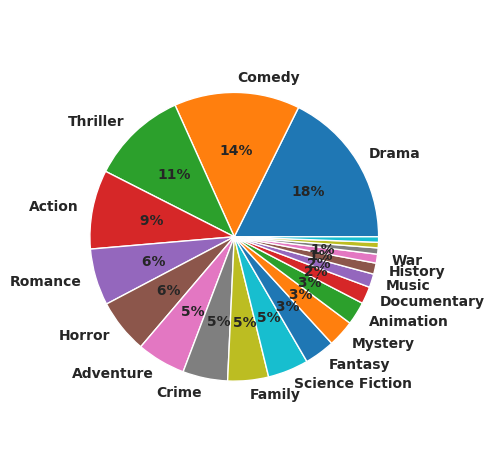

In [ ]:

i = 0
genre_count = []
for genre in total_genre_movies.index:
    genre_count.append([genre, total_genre_movies[i]])
    i = i+1

plt.rc('font', weight='bold')
f, ax = plt.subplots(figsize = (5, 5))
genre_count.sort(key = lambda x:x[1], reverse = True)
labels, sizes = zip(*genre_count)
labels_selected = [n if v > sum(sizes) * 0.01 else '' for n, v in genre_count]
ax.pie(sizes, labels = labels_selected,
       autopct = lambda x:'{:2.0f}%'.format(x) if x > 1 else '',
       shadow = False, startangle = 0)
ax.axis('equal')
plt.tight_layout()

In [ ]:
#extract the month number from the release date.
tmbd_eda['release_date'] = pd.to_datetime(tmbd_eda['release_date'])
month_release = tmbd_eda['release_date'].dt.month

#count the movies in each month using value_counts().
number_of_release = month_release.value_counts().sort_index()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
number_of_release = pd.DataFrame(number_of_release)
number_of_release['month'] = months

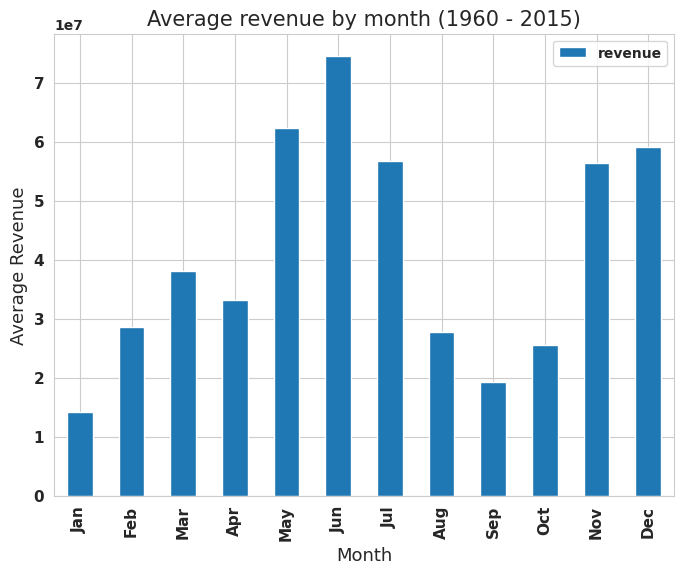

In [ ]:
#which month made the highest average revenue?.
#make a dataframe with in which store the release month of each movie.
month_release = pd.DataFrame(month_release)

#change the column name of the new dataframe 'month_release'.
month_release.rename(columns = {'release_date':'release_month'}, inplace = True)

#add a new column 'revenue' in the dataframe 'month_release'.
month_release['revenue'] = tmbd_eda['revenue']

#make the group of the data according to their month and calculate the mean revenue of each month.
mean_revenue  = month_release.groupby('release_month').mean()
mean_revenue['month'] = months

#make the bar plot using pandas plot function.
mean_revenue.plot(x ='month',kind ='bar',figsize = (8,6),fontsize=11)

#setup the title and lables of the plot.
plt.title('Average revenue by month (1960 - 2015)',fontsize = 15)
plt.xlabel('Month',fontsize = 13)
plt.ylabel('Average Revenue',fontsize = 13)
sns.set_style("darkgrid")

/tmp/ipykernel_11507/2453807890.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='revenue', y='original_title', data=top_10_revenue_movies, palette='viridis')


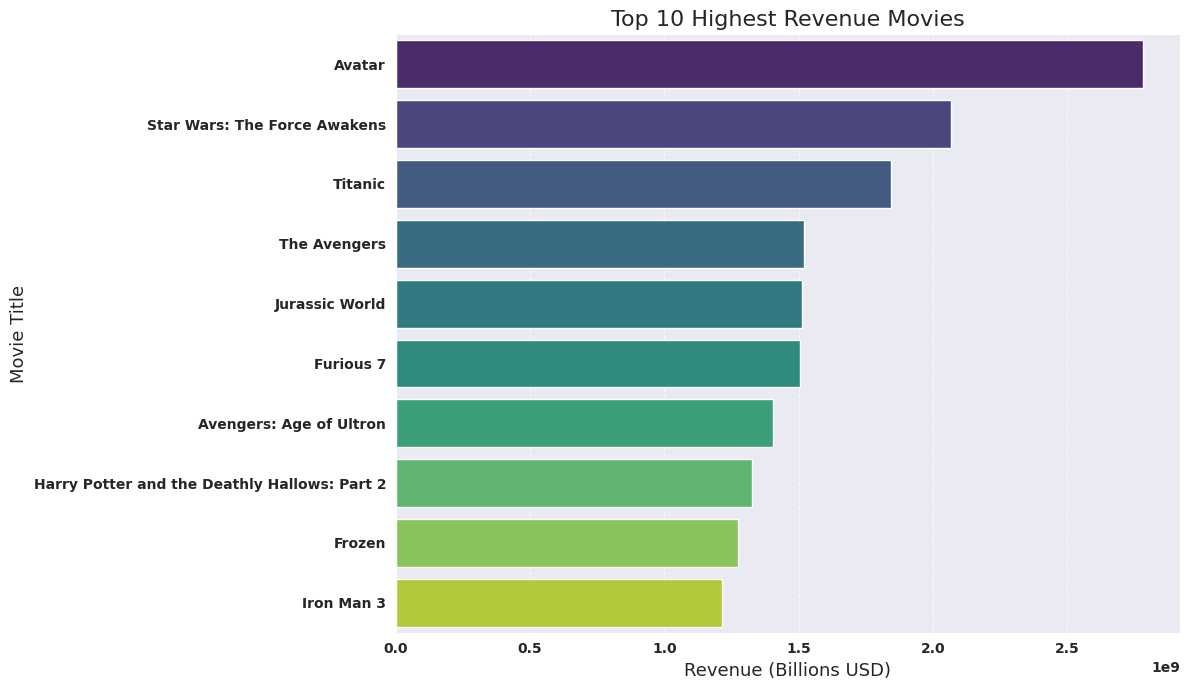

In [ ]:
# Sort the DataFrame by 'revenue' in descending order and select the top 10
top_10_revenue_movies = tmbd_eda.sort_values(by='revenue', ascending=False).head(10)

# Create a bar plot
plt.figure(figsize = (12, 7))
sns.barplot(x='revenue', y='original_title', data=top_10_revenue_movies, paletmbd_edae='viridis')

# Add titles and labels
plt.title('Top 10 Highest Revenue Movies', fontsize=16)
plt.xlabel('Revenue (Billions USD)', fontsize=13)
plt.ylabel('Movie Title', fontsize=13)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

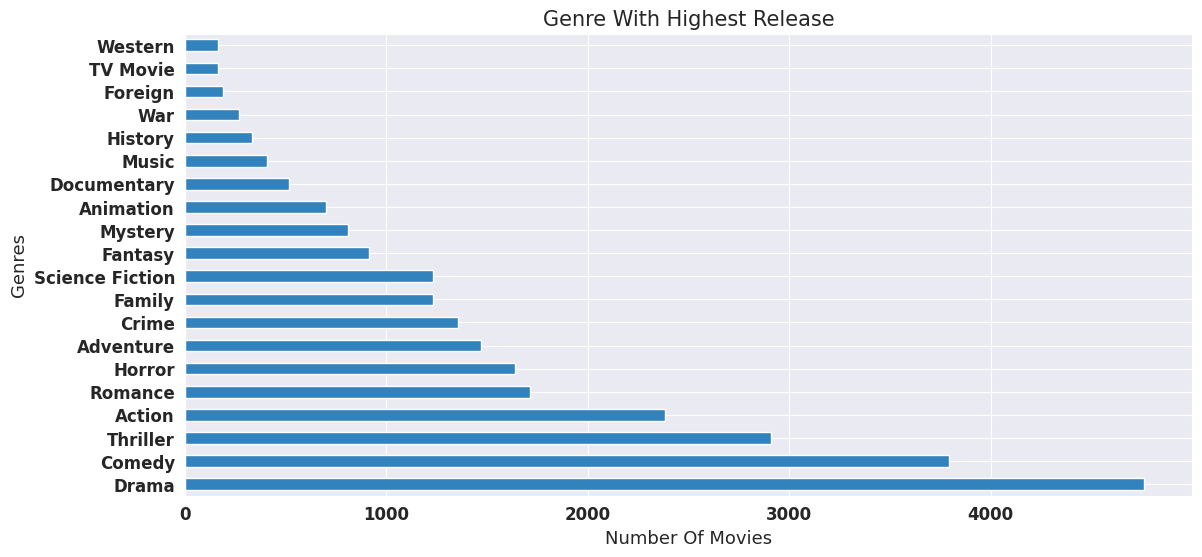

In [ ]:
def count_genre(x):
    #concatenate all the rows of the genres.
    data_plot = tmbd_eda[x].str.cat(sep = '|')
    data = pd.Series(data_plot.split('|'))
    #conts each of the genre and return.
    info = data.value_counts(ascending = False)
    return info

#call the function for counting the movies of each genre.
total_genre_movies = count_genre('genres')
#plot a 'barh' plot using plot function for 'genre vs number of movies'.
total_genre_movies.plot(kind= 'barh',figsize = (13,6),fontsize=12,colormap='tab20c')

#setup the title and the labels of the plot.
plt.title("Genre With Highest Release",fontsize=15)
plt.xlabel('Number Of Movies',fontsize=13)
plt.ylabel("Genres",fontsize= 13)
sns.set_style("whitegrid")

In [ ]:
genre_details = list(map(str,(tmbd_eda['genres'])))
genre = ['Adventure', 'Science Fiction', 'Fantasy', 'Crime', 'Western', 'Family','nan', 'Animation','War','Mystery','Romance','TV Movie','Action', 'Thriller','Comedy','Drama' , 'History', 'Music', 'Horror', 'Documentary', 'Foreign']

#make the numpy array of year and popularity which contain all the rows of release_year and popularity column.
year = np.array(tmbd_eda['release_year'])
popularity = np.array(tmbd_eda['popularity'])

#make a null dataframe which indexs are genres and columns are years.
popularity_df = pd.DataFrame(index = genre, columns = range(1960, 2016))
#change all the values of the dataframe from NAN to zero.
popularity_df = popularity_df.fillna(value = 0.0)

z = 0
for i in genre_details:
    split_genre = list(map(str,i.split('|')))
    popularity_df.loc[split_genre, year[z]] = popularity_df.loc[split_genre, year[z]] + popularity[z]
    z+=1

/tmp/ipykernel_11507/1933585423.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  popularity_df = popularity_df.fillna(value = 0.0)


<Axes: >

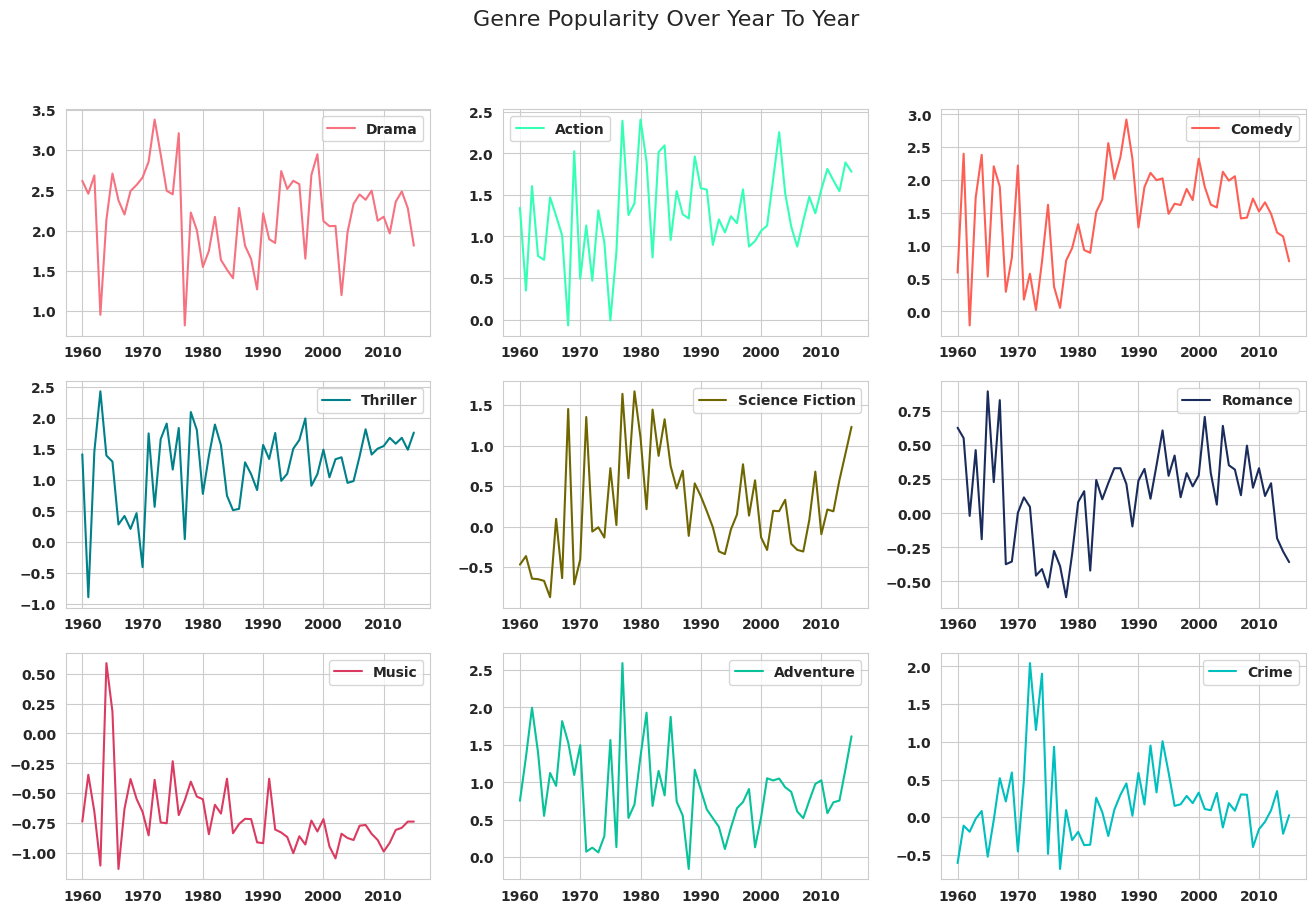

In [ ]:
def calculate_std(x):
    return (x-x.mean())/x.std(ddof=0)

popular_genre = calculate_std(popularity_df)

sns.set_style("whitegrid")
#make a subplot of size 3,3.
fig, ax = plt.subplots(3,3,figsize = (16,10))

#set the title of the subplot.
fig.suptitle('Genre Popularity Over Year To Year',fontsize = 16)

#plot the 'Drama' genre plot see the popularity difference over year to year.
popular_genre.loc['Drama'].plot(label = "Drama",color = '#f67280',ax = ax[0][0],legend=True)

#plot the 'Action' genre plot see the popularity difference over year to year.
popular_genre.loc['Action'].plot(label = "Action",color='#33FFB5',ax = ax[0][1],legend=True)

#plot the 'Comedy' genre plot see the popularity difference over year to year.
popular_genre.loc['Comedy'].plot(label = "Comedy",color='#fe5f55',ax = ax[0][2],legend=True)

#accordig to the previous plot the 'Thriller','Science Fiction', 'Romance', 'Music','Adventure' and 'Crime'.
popular_genre.loc['Thriller'].plot(label = "Thriller",color='#00818a',ax = ax[1][0],legend=True)
popular_genre.loc['Science Fiction'].plot(label = "Science Fiction",color='#6f6600',ax = ax[1][1],legend=True)
popular_genre.loc['Romance'].plot(label = "Romance",color='#1a2c5b',ax = ax[1][2],legend=True)
popular_genre.loc['Music'].plot(label = "Music",color='#db3b61',ax = ax[2][0],legend=True)
popular_genre.loc['Adventure'].plot(label = "Adventure",color='#08c299',ax = ax[2][1],legend=True)
popular_genre.loc['Crime'].plot(label = "Crime",color='c',ax = ax[2][2],legend=True)